# 02 — Exploratory Data Analysis

**Purpose:** understand the main PhonePe business patterns before creating the merchant-opportunity ranking.

Every chart is displayed directly below its topic. The code uses simple Pandas, Matplotlib, and Seaborn steps that can be explained line by line.

## 1. Load Prepared Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from phonepe_analytics.analysis import ANALYSIS_DIR
from phonepe_analytics.config import PROCESSED_DIR

sns.set_theme(style="whitegrid")
purple = "#5F259F"
teal = "#087F8C"
gray = "#697386"

district_data = pd.read_csv(ANALYSIS_DIR / "district_metrics.csv")
state_data = pd.read_csv(ANALYSIS_DIR / "state_metrics.csv")
national_data = pd.read_csv(
    ANALYSIS_DIR / "national_metrics.csv"
).sort_values("period_id")
category_data = pd.read_parquet(
    PROCESSED_DIR / "state_transaction_categories.parquet"
)

latest_period_id = district_data["period_id"].max()
latest_districts = district_data.loc[
    district_data["period_id"].eq(latest_period_id)
].copy()
latest_states = state_data.loc[
    state_data["period_id"].eq(latest_period_id)
].copy()
latest_period = latest_districts["period_label"].iloc[0]

analysis_scope = pd.DataFrame(
    {
        "latest_period": [latest_period],
        "districts": [len(latest_districts)],
        "states_and_uts": [len(latest_states)],
        "historical_quarters": [len(national_data)],
    }
)
display(analysis_scope)

,latest_period,districts,states_and_uts,historical_quarters
0,2026-Q2,783,36,34


### Insight

The EDA uses **2026-Q2** as the latest snapshot, with **783 districts** across **36 states/UTs**. Historical national trends use **34 quarters** from the same processed source.

## 2. Descriptive Statistics

In [2]:
selected_metrics = [
    "transaction_count",
    "transaction_amount",
    "registered_users",
    "registered_merchants",
    "average_transaction_value",
    "merchants_per_100k_users",
    "users_per_merchant",
    "transactions_per_registered_user",
    "tpv_per_registered_user",
    "transaction_qoq",
    "transaction_yoy",
    "user_qoq",
    "merchant_qoq",
]

descriptive_statistics = latest_districts[selected_metrics].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
).T
descriptive_statistics = descriptive_statistics.rename(
    columns={"50%": "median"}
)
descriptive_statistics = descriptive_statistics[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "75%",
        "90%",
        "max",
    ]
]
display(descriptive_statistics.round(3))

,count,mean,median,std,min,25%,75%,90%,max
transaction_count,783.0,4.937968e+07,2.444644e+07,1.111778e+08,2390.000,7.906492e+06,5.737864e+07,9.977271e+07,2.113433e+09
transaction_amount,783.0,5.810530e+10,2.949028e+10,1.197750e+11,2604556.220,9.090879e+09,6.739149e+10,1.310549e+11,2.237235e+12
registered_users,783.0,9.088803e+05,6.113150e+05,1.341768e+06,120.000,2.574440e+05,1.101086e+06,1.817077e+06,2.054306e+07
registered_merchants,783.0,6.475766e+04,3.885400e+04,1.084056e+05,1.000,1.341400e+04,7.465400e+04,1.374402e+05,1.517644e+06
average_transaction_value,783.0,1.236841e+03,1.192238e+03,2.298760e+02,753.458,1.095060e+03,1.340967e+03,1.534579e+03,2.810481e+03
merchants_per_100k_users,783.0,5.976175e+03,6.139588e+03,2.397867e+03,48.924,4.530877e+03,7.609214e+03,8.878458e+03,1.447934e+04
users_per_merchant,783.0,3.235200e+01,1.628800e+01,9.688200e+01,6.906,1.314200e+01,2.207100e+01,3.894700e+01,2.044000e+03
transactions_per_registered_user,783.0,4.392800e+01,4.071800e+01,2.289700e+01,5.929,2.762400e+01,5.406300e+01,7.813200e+01,1.202190e+02
tpv_per_registered_user,783.0,5.419152e+04,4.649192e+04,3.226021e+04,8390.438,3.263215e+04,6.420129e+04,9.636187e+04,1.725051e+05
transaction_qoq,783.0,8.900000e-02,7.300000e-02,1.070000e-01,-0.124,4.400000e-02,1.070000e-01,1.550000e-01,1.792000e+00


### Insight

The mean district transaction count is **49,379,675**, compared with a median of **24,446,442**. The large difference shows strong right skew caused by a small number of high-volume districts. Medians and percentiles are more useful than means for describing a typical district.

## 3. Univariate Analysis

### 3.1 Transaction Count Distribution

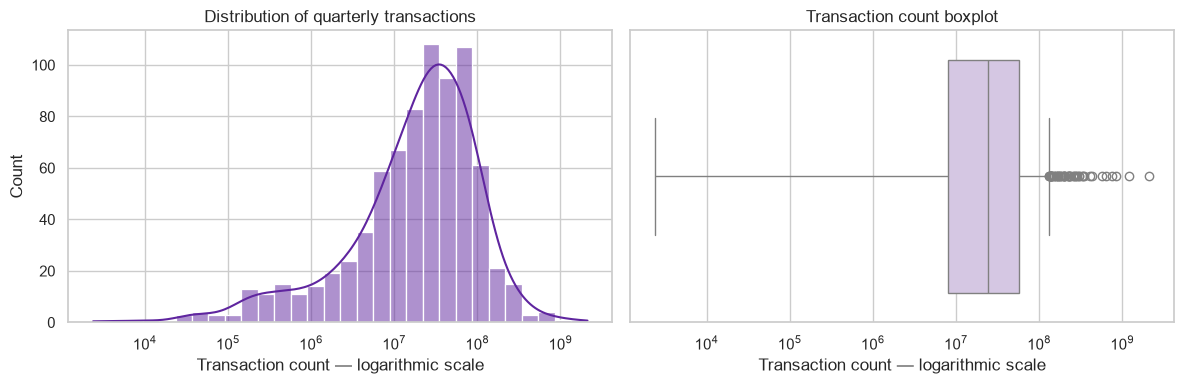

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="transaction_count",
    bins=30,
    kde=True,
    color=purple,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution of quarterly transactions")
axes[0].set_xlabel("Transaction count — logarithmic scale")

sns.boxplot(
    data=latest_districts,
    x="transaction_count",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Transaction count boxplot")
axes[1].set_xlabel("Transaction count — logarithmic scale")

fig.tight_layout()
plt.show()

### Insight

The median district processes **24,446,442 quarterly transactions**, while the maximum is **2,113,433,404**. The long upper tail represents major payment centres, so absolute demand should be combined with growth and merchant penetration.

### 3.2 Transaction Amount Distribution

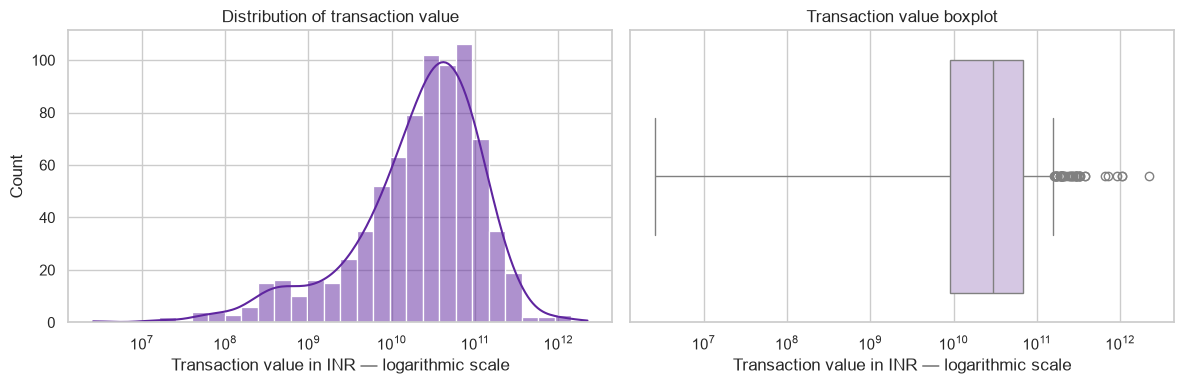

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="transaction_amount",
    bins=30,
    kde=True,
    color=purple,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution of transaction value")
axes[0].set_xlabel("Transaction value in INR — logarithmic scale")

sns.boxplot(
    data=latest_districts,
    x="transaction_amount",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Transaction value boxplot")
axes[1].set_xlabel("Transaction value in INR — logarithmic scale")

fig.tight_layout()
plt.show()

### Insight

Median quarterly transaction value is **INR 29.49 billion**, compared with a maximum of **INR 2237.23 billion**. The skew confirms that value concentration should be interpreted as market scale, not merchant revenue.

### 3.3 Registered Users Distribution

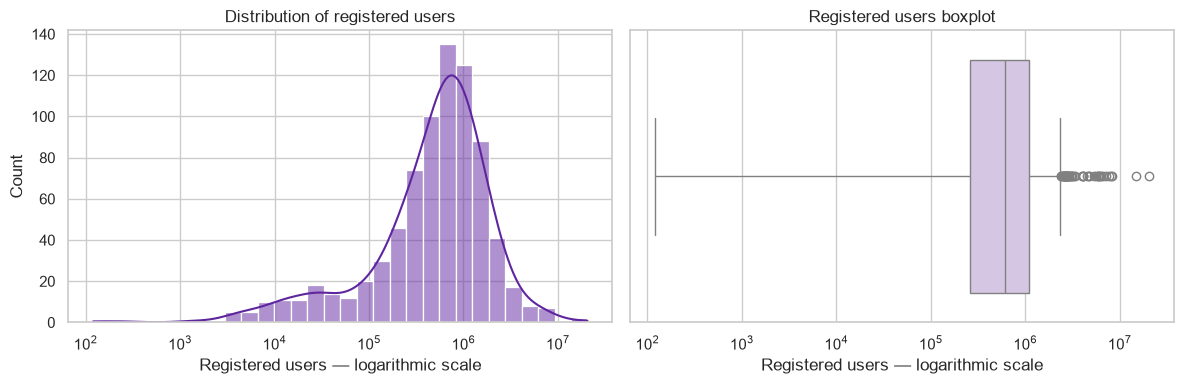

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="registered_users",
    bins=30,
    kde=True,
    color=purple,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution of registered users")
axes[0].set_xlabel("Registered users — logarithmic scale")

sns.boxplot(
    data=latest_districts,
    x="registered_users",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Registered users boxplot")
axes[1].set_xlabel("Registered users — logarithmic scale")

fig.tight_layout()
plt.show()

### Insight

The typical district has **611,315 registered users**, while the largest has **20,543,058**. User scale is useful for sizing a market, although registered users are not necessarily active users.

### 3.4 Registered Merchants Distribution

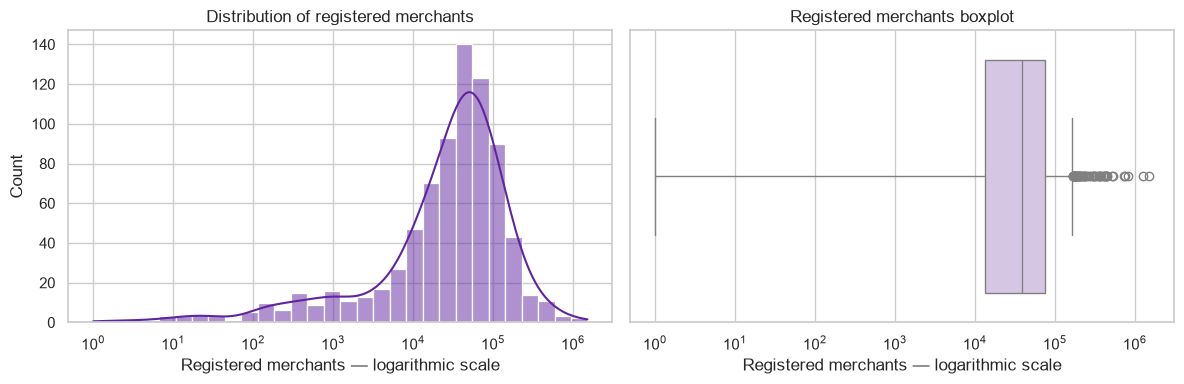

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="registered_merchants",
    bins=30,
    kde=True,
    color=purple,
    log_scale=True,
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Distribution of registered merchants")
axes[0].set_xlabel("Registered merchants — logarithmic scale")

sns.boxplot(
    data=latest_districts,
    x="registered_merchants",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_title("Registered merchants boxplot")
axes[1].set_xlabel("Registered merchants — logarithmic scale")

fig.tight_layout()
plt.show()

### Insight

Median merchant registration is **38,854 merchants per district**. The distribution is highly uneven, so merchant count needs to be divided by the user base before comparing relative coverage across districts.

### 3.5 Merchant Penetration Distribution

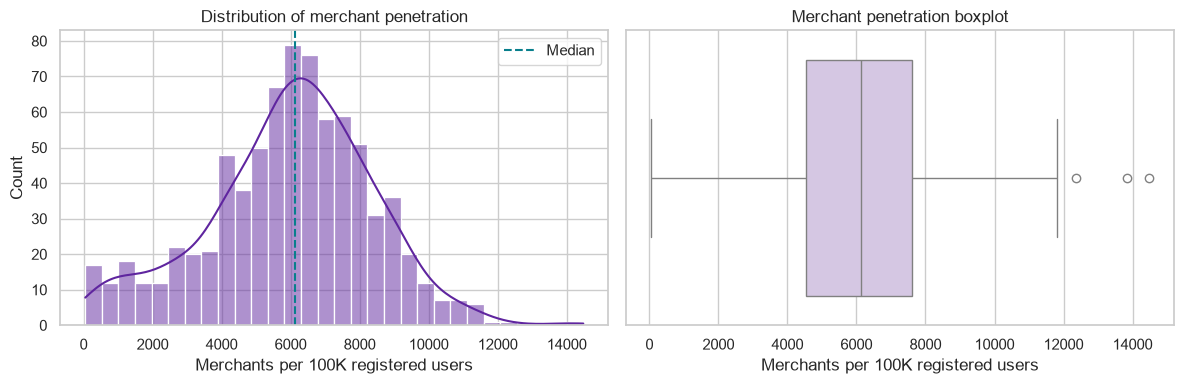

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="merchants_per_100k_users",
    bins=30,
    kde=True,
    color=purple,
    ax=axes[0],
)
axes[0].axvline(
    latest_districts["merchants_per_100k_users"].median(),
    color=teal,
    linestyle="--",
    label="Median",
)
axes[0].set_title("Distribution of merchant penetration")
axes[0].set_xlabel("Merchants per 100K registered users")
axes[0].legend()

sns.boxplot(
    data=latest_districts,
    x="merchants_per_100k_users",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_title("Merchant penetration boxplot")
axes[1].set_xlabel("Merchants per 100K registered users")

fig.tight_layout()
plt.show()

### Insight

Median merchant penetration is **6,140 merchants per 100K users**. The middle half lies between **4,531 and 7,609**. Low penetration is only a relative signal and must be paired with demand and user scale.

### 3.6 Transaction YoY Growth Distribution

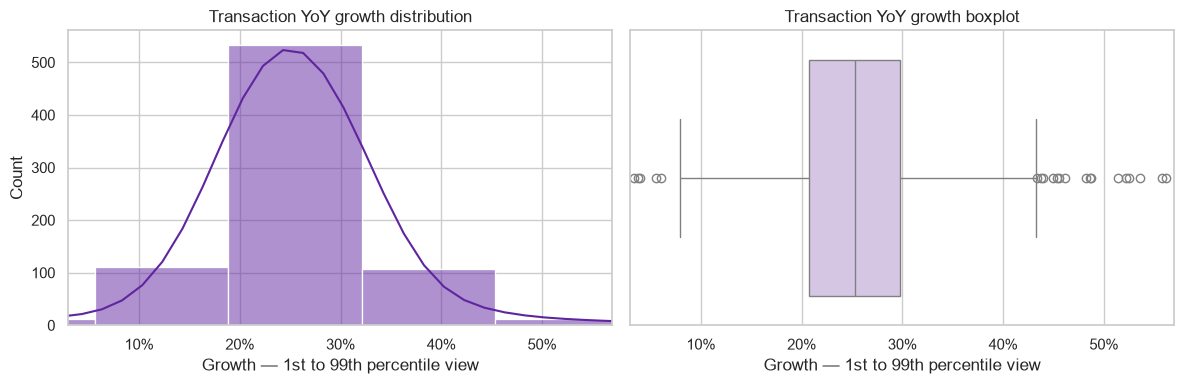

In [8]:
growth_lower_limit = latest_districts["transaction_yoy"].quantile(0.01)
growth_upper_limit = latest_districts["transaction_yoy"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=latest_districts,
    x="transaction_yoy",
    bins=30,
    kde=True,
    color=purple,
    ax=axes[0],
)
axes[0].set_xlim(growth_lower_limit, growth_upper_limit)
axes[0].xaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("Transaction YoY growth distribution")
axes[0].set_xlabel("Growth — 1st to 99th percentile view")

sns.boxplot(
    data=latest_districts,
    x="transaction_yoy",
    color="#D5C2E8",
    ax=axes[1],
)
axes[1].set_xlim(growth_lower_limit, growth_upper_limit)
axes[1].xaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title("Transaction YoY growth boxplot")
axes[1].set_xlabel("Growth — 1st to 99th percentile view")

fig.tight_layout()
plt.show()

### Insight

Median transaction YoY growth is **25.3%**. The maximum reaches **389.9%**, so the chart uses a 1st–99th percentile view for readability without changing or removing the original observations.

## 4. National Trend

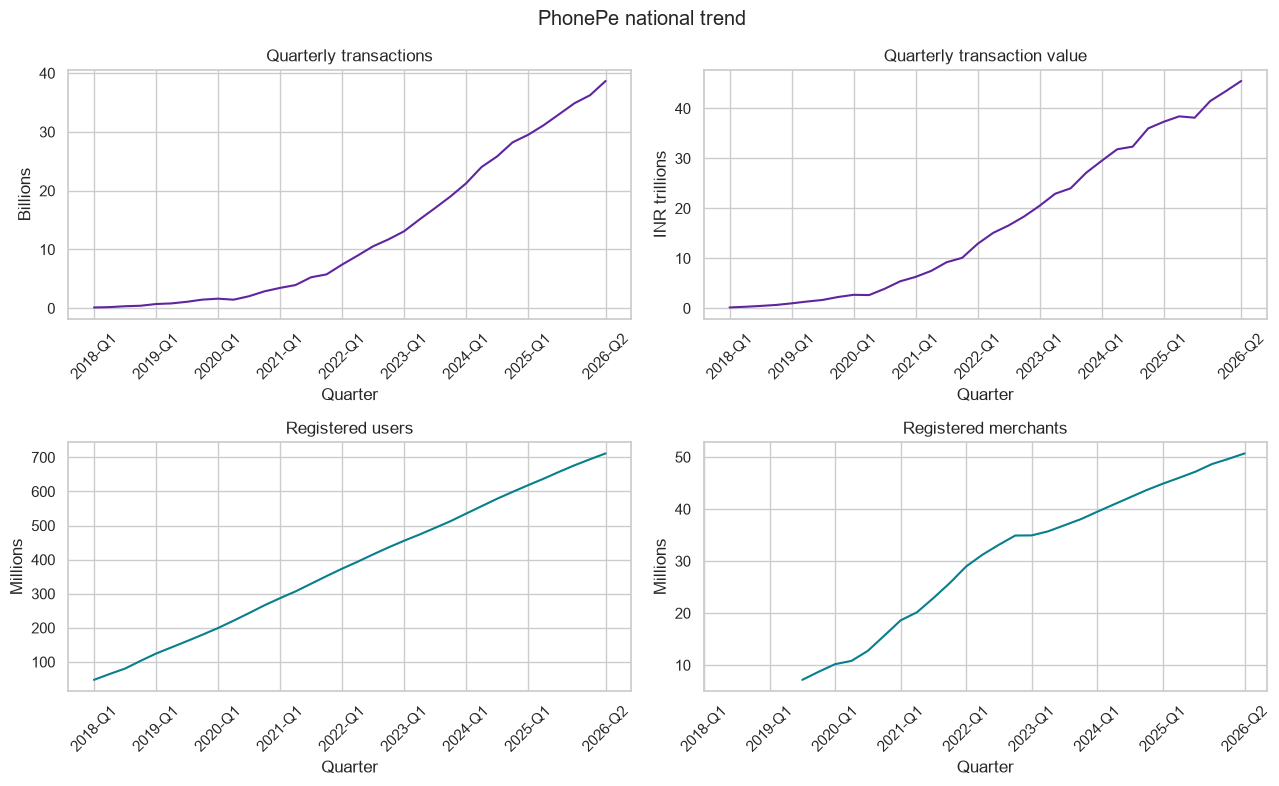

,metric,growth_percentage
0,Latest transaction QoQ growth,6.7%
1,Latest transaction-value QoQ growth,4.7%
2,Transaction growth since 2018 Q1,27521.6%
3,Registered-user growth since 2018 Q1,1398.7%


In [9]:
national_data["user_qoq"] = national_data["registered_users"].pct_change()
national_data["merchant_qoq"] = national_data[
    "registered_merchants"
].pct_change(fill_method=None)

tick_positions = list(range(0, len(national_data), 4))
tick_positions[-1] = len(national_data) - 1
tick_labels = national_data["period_label"].iloc[tick_positions]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(
    national_data["period_label"],
    national_data["transaction_count"] / 1_000_000_000,
    color=purple,
)
axes[0, 0].set_title("Quarterly transactions")
axes[0, 0].set_ylabel("Billions")

axes[0, 1].plot(
    national_data["period_label"],
    national_data["transaction_amount"] / 1_000_000_000_000,
    color=purple,
)
axes[0, 1].set_title("Quarterly transaction value")
axes[0, 1].set_ylabel("INR trillions")

axes[1, 0].plot(
    national_data["period_label"],
    national_data["registered_users"] / 1_000_000,
    color=teal,
)
axes[1, 0].set_title("Registered users")
axes[1, 0].set_ylabel("Millions")

axes[1, 1].plot(
    national_data["period_label"],
    national_data["registered_merchants"] / 1_000_000,
    color=teal,
)
axes[1, 1].set_title("Registered merchants")
axes[1, 1].set_ylabel("Millions")

for axis in axes.flat:
    axis.set_xticks(tick_positions, tick_labels, rotation=45)
    axis.set_xlabel("Quarter")

fig.suptitle("PhonePe national trend")
fig.tight_layout()
plt.show()

latest_national = national_data.iloc[-1]
first_national = national_data.iloc[0]

national_growth = pd.DataFrame(
    {
        "metric": [
            "Latest transaction QoQ growth",
            "Latest transaction-value QoQ growth",
            "Transaction growth since 2018 Q1",
            "Registered-user growth since 2018 Q1",
        ],
        "growth": [
            latest_national["transaction_qoq"],
            latest_national["tpv_qoq"],
            (
                latest_national["transaction_count"]
                / first_national["transaction_count"]
                - 1
            ),
            (
                latest_national["registered_users"]
                / first_national["registered_users"]
                - 1
            ),
        ],
    }
)
national_growth["growth_percentage"] = (
    national_growth["growth"].mul(100).round(1).astype(str) + "%"
)
display(national_growth[["metric", "growth_percentage"]])

### Insight

National transactions reached **38.66 billion** in 2026-Q2, with **6.7% QoQ growth**. Transaction value reached **INR 45.50 trillion**. National growth establishes overall demand but does not identify local merchant gaps.

## 5. State-Level Analysis

In [10]:
top_states_by_transactions = latest_states.nlargest(
    5,
    "transaction_count",
)[["state", "transaction_count"]]
top_states_by_value = latest_states.nlargest(
    5,
    "transaction_amount",
)[["state", "transaction_amount"]]
top_states_by_users = latest_states.nlargest(
    5,
    "registered_users",
)[["state", "registered_users"]]
top_states_by_merchants = latest_states.nlargest(
    5,
    "registered_merchants",
)[["state", "registered_merchants"]]

print("Top states by transactions")
display(top_states_by_transactions.reset_index(drop=True))
print("Top states by transaction value")
display(top_states_by_value.reset_index(drop=True))
print("Top states by registered users")
display(top_states_by_users.reset_index(drop=True))
print("Top states by registered merchants")
display(top_states_by_merchants.reset_index(drop=True))

Top states by transactions


,state,transaction_count
0,maharashtra,5064451991
1,karnataka,4491711923
2,telangana,3878232440
3,uttar pradesh,3665306240
4,andhra pradesh,3245956863


Top states by transaction value


,state,transaction_amount
0,maharashtra,5.465177e+12
1,karnataka,5.292341e+12
2,telangana,5.128046e+12
3,andhra pradesh,4.623697e+12
4,uttar pradesh,3.938705e+12


Top states by registered users


,state,registered_users
0,uttar pradesh,90563992
1,maharashtra,84075442
2,karnataka,52534800
3,bihar,44813491
4,rajasthan,43692290


Top states by registered merchants


,state,registered_merchants
0,uttar pradesh,7866204.0
1,maharashtra,6113793.0
2,west bengal,3631496.0
3,rajasthan,3314270.0
4,karnataka,3305459.0


,group,transaction_share
0,Top five states,52.6%
1,Top ten states,79.6%


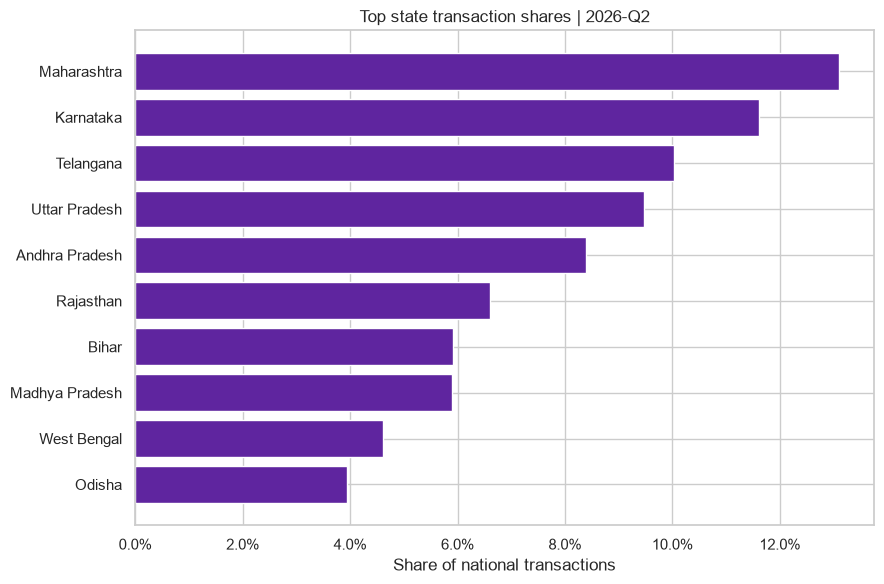

In [11]:
state_transaction_ranking = latest_states.sort_values(
    "transaction_count",
    ascending=False,
).copy()
state_transaction_ranking["transaction_share"] = (
    state_transaction_ranking["transaction_count"]
    / state_transaction_ranking["transaction_count"].sum()
)

top_five_share = state_transaction_ranking.head(5)[
    "transaction_share"
].sum()
top_ten_share = state_transaction_ranking.head(10)[
    "transaction_share"
].sum()

concentration = pd.DataFrame(
    {
        "group": ["Top five states", "Top ten states"],
        "transaction_share": [top_five_share, top_ten_share],
    }
)
concentration["transaction_share"] = (
    concentration["transaction_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(concentration)

chart_data = state_transaction_ranking.head(10).sort_values(
    "transaction_share"
)
fig, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    chart_data["state"].str.title(),
    chart_data["transaction_share"],
    color=purple,
)
axis.xaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(f"Top state transaction shares | {latest_period}")
axis.set_xlabel("Share of national transactions")
axis.set_ylabel("")
fig.tight_layout()
plt.show()

### Insight

**Maharashtra** leads state transaction volume. The top five states contribute **52.6%**, and the top ten contribute **79.6%**. Large states offer scale, but district-level penetration is needed before identifying expansion targets.

## 6. District-Level Demand

Growth and merchant-penetration comparisons use districts with at least **100,000 registered users**, **1,000 registered merchants**, **1 million quarterly transactions**, and complete user, merchant, and transaction-growth history. These thresholds reduce unstable comparisons from very small denominators.

In [12]:
sizeable_districts = latest_districts.loc[
    latest_districts["registered_users"].ge(100_000)
    & latest_districts["registered_merchants"].ge(1_000)
    & latest_districts["transaction_count"].ge(1_000_000)
    & latest_districts[
        ["transaction_yoy", "user_qoq", "merchant_qoq"]
    ].notna().all(axis=1)
].copy()

print(
    f"Sizeable districts: {len(sizeable_districts):,} "
    f"of {len(latest_districts):,}"
)

Sizeable districts: 680 of 783


### 6.1 Largest Districts

In [13]:
largest_by_transactions = latest_districts.nlargest(
    10,
    "transaction_count",
)[
    [
        "state",
        "district",
        "transaction_count",
        "registered_users",
        "transaction_yoy",
        "merchants_per_100k_users",
    ]
]
largest_by_users = latest_districts.nlargest(
    10,
    "registered_users",
)[
    [
        "state",
        "district",
        "registered_users",
        "transaction_count",
        "transaction_yoy",
        "merchants_per_100k_users",
    ]
]

print("Largest districts by transactions")
display(largest_by_transactions.reset_index(drop=True))
print("Largest districts by registered users")
display(largest_by_users.reset_index(drop=True))

Largest districts by transactions


,state,district,transaction_count,registered_users,transaction_yoy,merchants_per_100k_users
0,karnataka,bengaluru urban,2.113433e+09,20543058,0.173172,7387.624569
1,maharashtra,pune,1.190116e+09,14753740,0.230502,8552.441618
2,telangana,rangareddy,8.453297e+08,7229570,0.254740,6253.719101
3,telangana,medchal malkajgiri,7.590408e+08,6313836,0.240344,7211.115398
4,rajasthan,jaipur,6.372599e+08,7999367,0.159128,10172.004860
5,telangana,hyderabad,5.720922e+08,5840094,0.213475,7422.175054
6,uttar pradesh,gautambuddha nagar,4.314158e+08,5609621,0.217466,7606.627970
7,haryana,gurugram,4.052013e+08,5282943,0.195865,6768.840777
8,maharashtra,thane,3.464772e+08,8346491,0.249760,8882.175755
9,madhya pradesh,indore,3.398951e+08,4118995,0.219451,8691.707565


Largest districts by registered users


,state,district,registered_users,transaction_count,transaction_yoy,merchants_per_100k_users
0,karnataka,bengaluru urban,20543058,2.113433e+09,0.173172,7387.624569
1,maharashtra,pune,14753740,1.190116e+09,0.230502,8552.441618
2,maharashtra,thane,8346491,3.464772e+08,0.249760,8882.175755
3,rajasthan,jaipur,7999367,6.372599e+08,0.159128,10172.004860
4,maharashtra,mumbai suburban,7625449,2.819981e+08,0.229858,9831.814494
5,telangana,rangareddy,7229570,8.453297e+08,0.254740,6253.719101
6,gujarat,ahmedabad,6724772,2.607001e+08,0.270977,7660.155616
7,telangana,medchal malkajgiri,6313836,7.590408e+08,0.240344,7211.115398
8,tamil nadu,chennai,6215686,1.796799e+08,0.157302,6714.624902
9,west bengal,north twenty four parganas,6080783,2.709292e+08,0.229787,8656.237198


### 6.2 Growth and Merchant Penetration

In [14]:
fastest_growing = sizeable_districts.nlargest(
    10,
    "transaction_yoy",
)[
    [
        "state",
        "district",
        "transaction_yoy",
        "transaction_count",
        "registered_users",
        "merchants_per_100k_users",
    ]
]
lowest_penetration = sizeable_districts.nsmallest(
    10,
    "merchants_per_100k_users",
)[
    [
        "state",
        "district",
        "merchants_per_100k_users",
        "users_per_merchant",
        "transaction_count",
        "transaction_yoy",
    ]
]

print("Fastest-growing sizeable districts")
display(fastest_growing.reset_index(drop=True))
print("Lowest-penetration sizeable districts")
display(lowest_penetration.reset_index(drop=True))

Fastest-growing sizeable districts


,state,district,transaction_yoy,transaction_count,registered_users,merchants_per_100k_users
0,assam,darrang,0.524498,21610773.0,412727,8629.917597
1,mizoram,aizawl,0.482547,2457520.0,164163,9994.334899
2,assam,morigaon,0.455173,18226572.0,432252,7595.106558
3,bihar,jehanabad,0.434015,20442084.0,416235,4292.767307
4,punjab,kapurthala,0.433081,10609846.0,364471,6039.163610
5,gujarat,jamnagar,0.431148,21411527.0,728437,4454.468952
6,assam,udalguri,0.431144,8475087.0,285968,6700.400045
7,meghalaya,east khasi hills,0.422817,6655012.0,253230,2656.083402
8,assam,kamrup,0.418580,28257339.0,710607,7520.894109
9,assam,hojai,0.411021,19368667.0,442831,6139.588240


Lowest-penetration sizeable districts


,state,district,merchants_per_100k_users,users_per_merchant,transaction_count,transaction_yoy
0,ladakh,leh ladakh,915.430826,109.238183,6775664.0,0.190227
1,chhattisgarh,bijapur,1166.049585,85.759646,4987418.0,0.120457
2,chhattisgarh,dantewada,1900.172005,52.626815,5794933.0,0.149878
3,himachal pradesh,shimla,2199.185112,45.471388,7992452.0,0.131379
4,jharkhand,gumla,2234.479220,44.753157,8157749.0,0.205061
5,gujarat,narmada,2240.029032,44.642279,4126831.0,0.206592
6,jharkhand,jamtara,2352.653227,42.505202,7915444.0,0.189194
7,jharkhand,simdega,2456.514467,40.708085,3902634.0,0.239025
8,gujarat,morbi,2464.408081,40.577695,17114095.0,0.097571
9,goa,south goa,2485.683791,40.230379,22941591.0,0.154569


### 6.3 Districts Appearing in Multiple Lists

In [15]:
transaction_signals = largest_by_transactions[
    ["state", "district"]
].assign(signal="High transactions")
user_signals = largest_by_users[
    ["state", "district"]
].assign(signal="Large user base")
growth_signals = fastest_growing[
    ["state", "district"]
].assign(signal="Fast growth")
penetration_signals = lowest_penetration[
    ["state", "district"]
].assign(signal="Low penetration")

all_signals = pd.concat(
    [
        transaction_signals,
        user_signals,
        growth_signals,
        penetration_signals,
    ],
    ignore_index=True,
)
repeated_districts = (
    all_signals.groupby(["state", "district"])
    .agg(
        signal_count=("signal", "size"),
        signals=("signal", ", ".join),
    )
    .query("signal_count >= 2")
    .sort_values("signal_count", ascending=False)
    .reset_index()
)
display(repeated_districts)

,state,district,signal_count,signals
0,karnataka,bengaluru urban,2,"High transactions, Large user base"
1,maharashtra,pune,2,"High transactions, Large user base"
2,maharashtra,thane,2,"High transactions, Large user base"
3,rajasthan,jaipur,2,"High transactions, Large user base"
4,telangana,medchal malkajgiri,2,"High transactions, Large user base"
5,telangana,rangareddy,2,"High transactions, Large user base"


### Insight

**Bengaluru Urban** leads transactions, and **Darrang** has the fastest sizeable-district YoY growth. Repeated appearance across scale, growth, and low-penetration tables is stronger exploratory evidence than one isolated ranking.

## 7. Merchant Penetration Analysis

In [16]:
penetration_summary = sizeable_districts[
    ["merchants_per_100k_users", "users_per_merchant"]
].quantile([0.25, 0.50, 0.75])
penetration_summary.index = [
    "25th percentile",
    "Median",
    "75th percentile",
]
display(penetration_summary.round(2))

penetration_columns = [
    "state",
    "district",
    "merchants_per_100k_users",
    "users_per_merchant",
    "registered_users",
    "transaction_yoy",
]

print("Lowest merchant penetration")
display(
    sizeable_districts.nsmallest(
        10,
        "merchants_per_100k_users",
    )[penetration_columns].reset_index(drop=True)
)

print("Highest merchant penetration")
display(
    sizeable_districts.nlargest(
        10,
        "merchants_per_100k_users",
    )[penetration_columns].reset_index(drop=True)
)

,merchants_per_100k_users,users_per_merchant
25th percentile,5278.22,12.90
Median,6441.49,15.52
75th percentile,7751.07,18.95


Lowest merchant penetration


,state,district,merchants_per_100k_users,users_per_merchant,registered_users,transaction_yoy
0,ladakh,leh ladakh,915.430826,109.238183,177949,0.190227
1,chhattisgarh,bijapur,1166.049585,85.759646,106685,0.120457
2,chhattisgarh,dantewada,1900.172005,52.626815,123252,0.149878
3,himachal pradesh,shimla,2199.185112,45.471388,434661,0.131379
4,jharkhand,gumla,2234.479220,44.753157,272860,0.205061
5,gujarat,narmada,2240.029032,44.642279,170846,0.206592
6,jharkhand,jamtara,2352.653227,42.505202,335026,0.189194
7,jharkhand,simdega,2456.514467,40.708085,143496,0.239025
8,gujarat,morbi,2464.408081,40.577695,731697,0.097571
9,goa,south goa,2485.683791,40.230379,625864,0.154569


Highest merchant penetration


,state,district,merchants_per_100k_users,users_per_merchant,registered_users,transaction_yoy
0,madhya pradesh,burhanpur,14479.338554,6.906393,343006,0.246424
1,uttar pradesh,bhadohi,13837.699514,7.226635,522081,0.294393
2,madhya pradesh,bhopal,12350.471867,8.096857,2930803,0.211092
3,west bengal,murshidabad,11814.128139,8.464442,3131835,0.258517
4,uttar pradesh,sambhal,11509.469662,8.688498,819195,0.295387
5,uttar pradesh,shamli,11295.391785,8.853168,602945,0.248468
6,delhi,south east,11272.471249,8.871169,2525338,0.193899
7,haryana,kaithal,11231.031405,8.903902,492920,0.252377
8,rajasthan,kota,11183.113198,8.942054,1566004,0.213193
9,uttar pradesh,shravasti,11126.541309,8.987519,267873,0.346711


### Insight

Sizeable districts have a median of **6,441 merchants per 100K users**. Lower penetration may indicate a registration gap, but it becomes commercially interesting only when demand and user scale are also meaningful.

## 8. User Growth vs Merchant Growth

In [17]:
sizeable_districts["growth_gap"] = (
    sizeable_districts["user_qoq"]
    - sizeable_districts["merchant_qoq"]
)
user_growth_leads = sizeable_districts["growth_gap"].gt(0)

growth_gap_summary = pd.DataFrame(
    {
        "measure": [
            "User growth exceeds merchant growth",
            "Merchant growth meets or exceeds user growth",
        ],
        "district_count": [
            int(user_growth_leads.sum()),
            int((~user_growth_leads).sum()),
        ],
        "district_share": [
            user_growth_leads.mean(),
            (~user_growth_leads).mean(),
        ],
    }
)
growth_gap_summary["district_share"] = (
    growth_gap_summary["district_share"]
    .mul(100)
    .round(1)
    .astype(str)
    + "%"
)
display(growth_gap_summary)

gap_columns = [
    "state",
    "district",
    "user_qoq",
    "merchant_qoq",
    "growth_gap",
    "registered_users",
]
display(
    sizeable_districts.nlargest(10, "growth_gap")[
        gap_columns
    ].reset_index(drop=True)
)

,measure,district_count,district_share
0,User growth exceeds merchant growth,338,49.7%
1,Merchant growth meets or exceeds user growth,342,50.3%


,state,district,user_qoq,merchant_qoq,growth_gap,registered_users
0,jammu & kashmir,ganderbal,0.178974,0.024228,0.154746,128599
1,jammu & kashmir,anantnag,0.101392,0.023671,0.077721,396835
2,tamil nadu,kancheepuram,0.050545,0.011062,0.039483,1058912
3,chhattisgarh,bijapur,0.040880,0.003226,0.037654,106685
4,ladakh,leh ladakh,0.047116,0.011801,0.035315,177949
5,punjab,moga,0.044561,0.009405,0.035156,319177
6,punjab,barnala,0.049927,0.015075,0.034851,208611
7,punjab,mansa,0.045187,0.012016,0.033171,255495
8,punjab,tarn taran,0.044757,0.013353,0.031404,360111
9,punjab,sri muktsar sahib,0.040298,0.009485,0.030813,323828


### Insight

User growth exceeds merchant growth in **49.7% of sizeable districts**. This may justify merchant-coverage investigation, but it is not proof of a merchant shortage because registered users and merchants may be inactive.

## 9. Bivariate Analysis

### 9.1 Registered Users vs Transactions

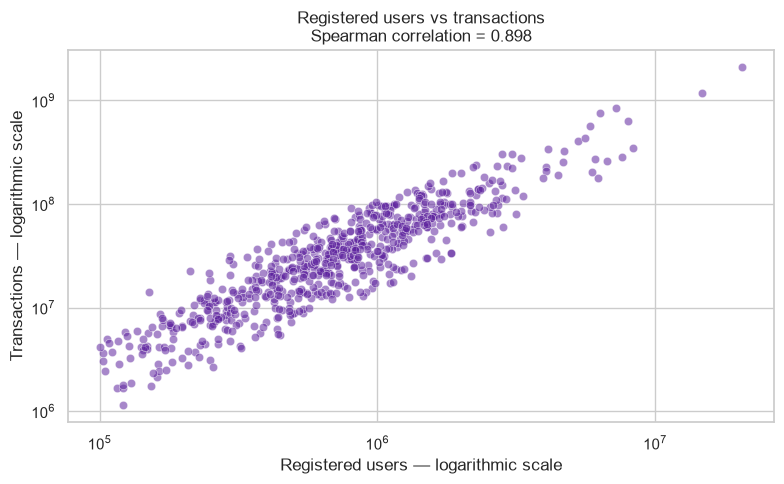

In [18]:
users_transactions_correlation = sizeable_districts[
    ["registered_users", "transaction_count"]
].corr(method="spearman").iloc[0, 1]

fig, axis = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sizeable_districts,
    x="registered_users",
    y="transaction_count",
    color=purple,
    alpha=0.55,
    ax=axis,
)
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_title(
    "Registered users vs transactions\n"
    f"Spearman correlation = {users_transactions_correlation:.3f}"
)
axis.set_xlabel("Registered users — logarithmic scale")
axis.set_ylabel("Transactions — logarithmic scale")
fig.tight_layout()
plt.show()

### Insight

Registered users and transactions have a **0.898 Spearman correlation**. Larger user bases usually support more transactions, so user scale and transaction volume contain overlapping information.

### 9.2 Registered Merchants vs Transactions

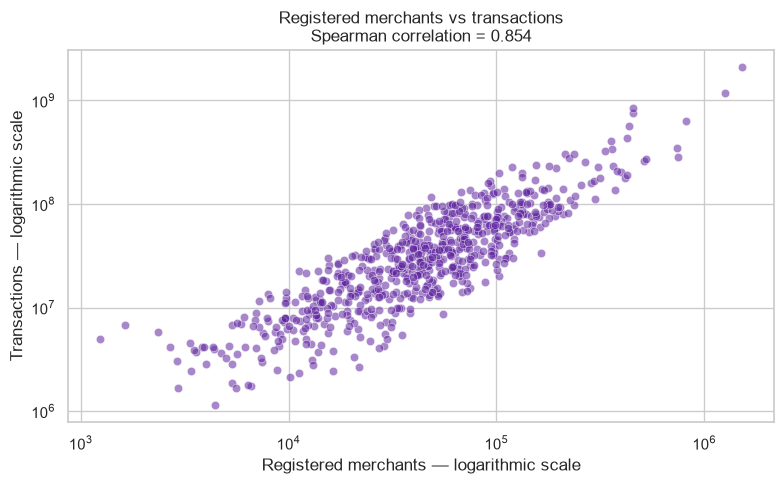

In [19]:
merchants_transactions_correlation = sizeable_districts[
    ["registered_merchants", "transaction_count"]
].corr(method="spearman").iloc[0, 1]

fig, axis = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sizeable_districts,
    x="registered_merchants",
    y="transaction_count",
    color=purple,
    alpha=0.55,
    ax=axis,
)
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_title(
    "Registered merchants vs transactions\n"
    f"Spearman correlation = {merchants_transactions_correlation:.3f}"
)
axis.set_xlabel("Registered merchants — logarithmic scale")
axis.set_ylabel("Transactions — logarithmic scale")
fig.tight_layout()
plt.show()

### Insight

Registered merchants and transactions have a **0.854 Spearman correlation**. Larger merchant networks are associated with larger transaction markets, but the chart cannot show that merchant additions caused activity.

### 9.3 Merchant Penetration vs Transaction Growth

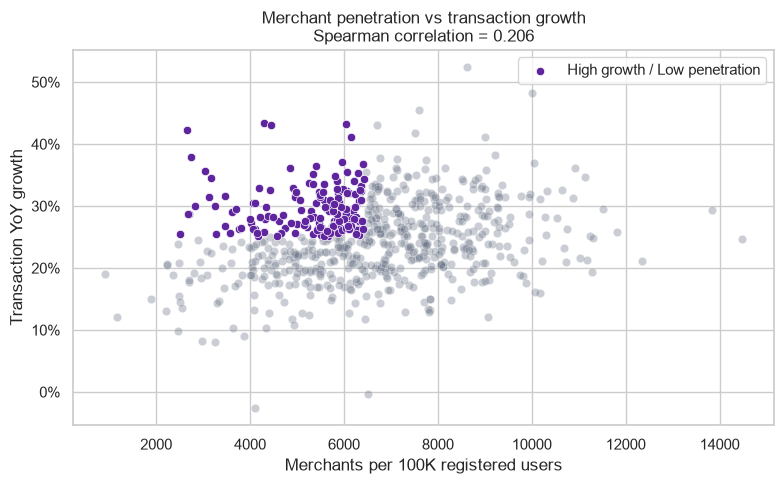

In [20]:
penetration_growth_correlation = sizeable_districts[
    ["merchants_per_100k_users", "transaction_yoy"]
].corr(method="spearman").iloc[0, 1]

low_penetration = sizeable_districts[
    "merchants_per_100k_users"
].lt(sizeable_districts["merchants_per_100k_users"].median())
high_growth = sizeable_districts["transaction_yoy"].ge(
    sizeable_districts["transaction_yoy"].median()
)
highlighted = low_penetration & high_growth

fig, axis = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sizeable_districts,
    x="merchants_per_100k_users",
    y="transaction_yoy",
    color=gray,
    alpha=0.35,
    ax=axis,
)
sns.scatterplot(
    data=sizeable_districts.loc[highlighted],
    x="merchants_per_100k_users",
    y="transaction_yoy",
    color=purple,
    label="High growth / Low penetration",
    ax=axis,
)
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(
    "Merchant penetration vs transaction growth\n"
    f"Spearman correlation = {penetration_growth_correlation:.3f}"
)
axis.set_xlabel("Merchants per 100K registered users")
axis.set_ylabel("Transaction YoY growth")
fig.tight_layout()
plt.show()

### Insight

Merchant penetration and transaction growth have a weak **0.206 correlation**. Low penetration does not automatically produce high growth; the highlighted districts simply combine both signals and merit deeper investigation.

### 9.4 User Growth vs Merchant Growth

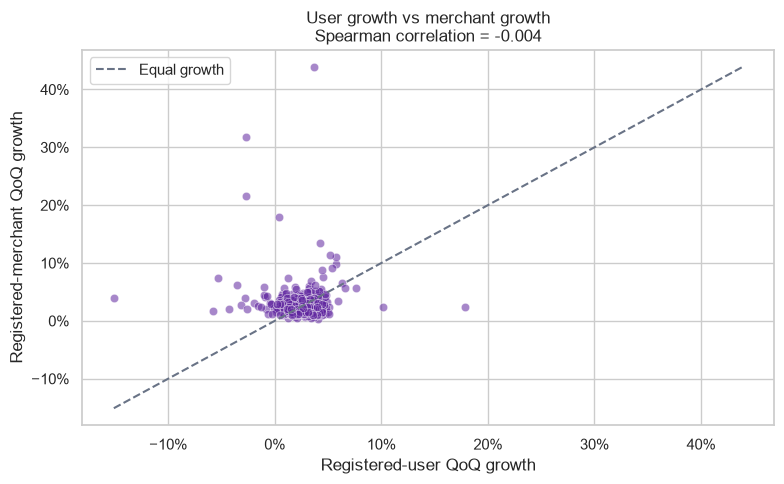

In [21]:
growth_correlation = sizeable_districts[
    ["user_qoq", "merchant_qoq"]
].corr(method="spearman").iloc[0, 1]

minimum_growth = min(
    sizeable_districts["user_qoq"].min(),
    sizeable_districts["merchant_qoq"].min(),
)
maximum_growth = max(
    sizeable_districts["user_qoq"].max(),
    sizeable_districts["merchant_qoq"].max(),
)

fig, axis = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=sizeable_districts,
    x="user_qoq",
    y="merchant_qoq",
    color=purple,
    alpha=0.55,
    ax=axis,
)
axis.plot(
    [minimum_growth, maximum_growth],
    [minimum_growth, maximum_growth],
    color=gray,
    linestyle="--",
    label="Equal growth",
)
axis.xaxis.set_major_formatter(PercentFormatter(1))
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(
    "User growth vs merchant growth\n"
    f"Spearman correlation = {growth_correlation:.3f}"
)
axis.set_xlabel("Registered-user QoQ growth")
axis.set_ylabel("Registered-merchant QoQ growth")
axis.legend()
fig.tight_layout()
plt.show()

### Insight

User and merchant growth have a **-0.004 correlation**. Points below the reference line show districts where merchant registrations grow more slowly than users, which is useful for screening but not proof of inadequate coverage.

## 10. Multivariate Analysis

### 10.1 Growth, Merchant Penetration, and User Scale

In [22]:
penetration_median = sizeable_districts[
    "merchants_per_100k_users"
].median()
growth_median = sizeable_districts["transaction_yoy"].median()

high_growth = sizeable_districts["transaction_yoy"].ge(growth_median)
low_penetration = sizeable_districts[
    "merchants_per_100k_users"
].lt(penetration_median)

sizeable_districts["quadrant"] = "Low growth / High penetration"
sizeable_districts.loc[
    high_growth & low_penetration,
    "quadrant",
] = "High growth / Low penetration"
sizeable_districts.loc[
    high_growth & ~low_penetration,
    "quadrant",
] = "High growth / High penetration"
sizeable_districts.loc[
    ~high_growth & low_penetration,
    "quadrant",
] = "Low growth / Low penetration"

quadrant_counts = (
    sizeable_districts["quadrant"]
    .value_counts()
    .rename("district_count")
    .rename_axis("quadrant")
    .reset_index()
)
display(quadrant_counts)

,quadrant,district_count
0,Low growth / Low penetration,194
1,High growth / High penetration,194
2,High growth / Low penetration,146
3,Low growth / High penetration,146


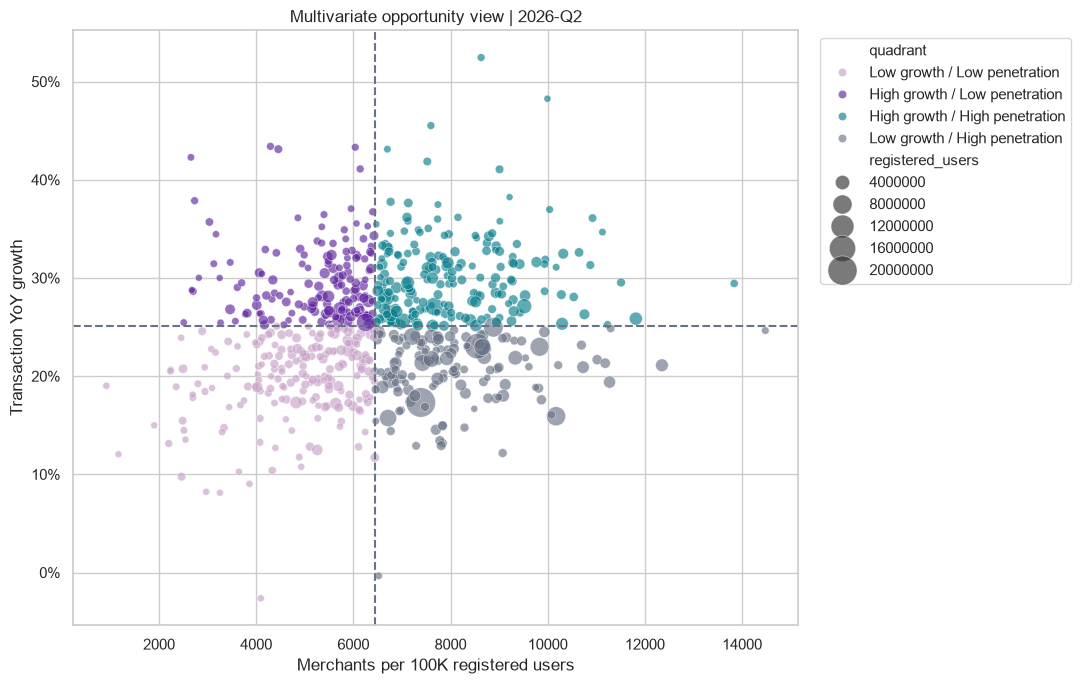

In [23]:
quadrant_colors = {
    "High growth / Low penetration": purple,
    "High growth / High penetration": teal,
    "Low growth / Low penetration": "#C8A2C8",
    "Low growth / High penetration": gray,
}

fig, axis = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=sizeable_districts,
    x="merchants_per_100k_users",
    y="transaction_yoy",
    size="registered_users",
    hue="quadrant",
    palette=quadrant_colors,
    sizes=(25, 450),
    alpha=0.65,
    ax=axis,
)
axis.axvline(penetration_median, color=gray, linestyle="--")
axis.axhline(growth_median, color=gray, linestyle="--")
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(f"Multivariate opportunity view | {latest_period}")
axis.set_xlabel("Merchants per 100K registered users")
axis.set_ylabel("Transaction YoY growth")
axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

In [24]:
exploratory_candidates = sizeable_districts.loc[
    sizeable_districts["quadrant"].eq(
        "High growth / Low penetration"
    )
].copy()

candidate_share = len(exploratory_candidates) / len(sizeable_districts)
candidate_states = (
    exploratory_candidates["state"]
    .value_counts()
    .rename("candidate_count")
    .rename_axis("state")
    .reset_index()
)

print(f"Candidate districts: {len(exploratory_candidates)}")
print(f"Candidate share: {candidate_share:.1%}")
display(candidate_states.head(10))

Candidate districts: 146
Candidate share: 21.5%


,state,candidate_count
0,maharashtra,19
1,andhra pradesh,17
2,gujarat,14
3,telangana,14
4,assam,13
5,bihar,10
6,karnataka,9
7,punjab,8
8,madhya pradesh,7
9,jharkhand,5


### Insight

The high-growth, low-penetration quadrant contains **146 districts (21.5%)**. **Maharashtra** contains the most, with **19 districts**. Bubble size adds user scale, helping separate commercially meaningful candidates from small markets. This remains exploratory and is not the final score.

## 11. Correlation Analysis

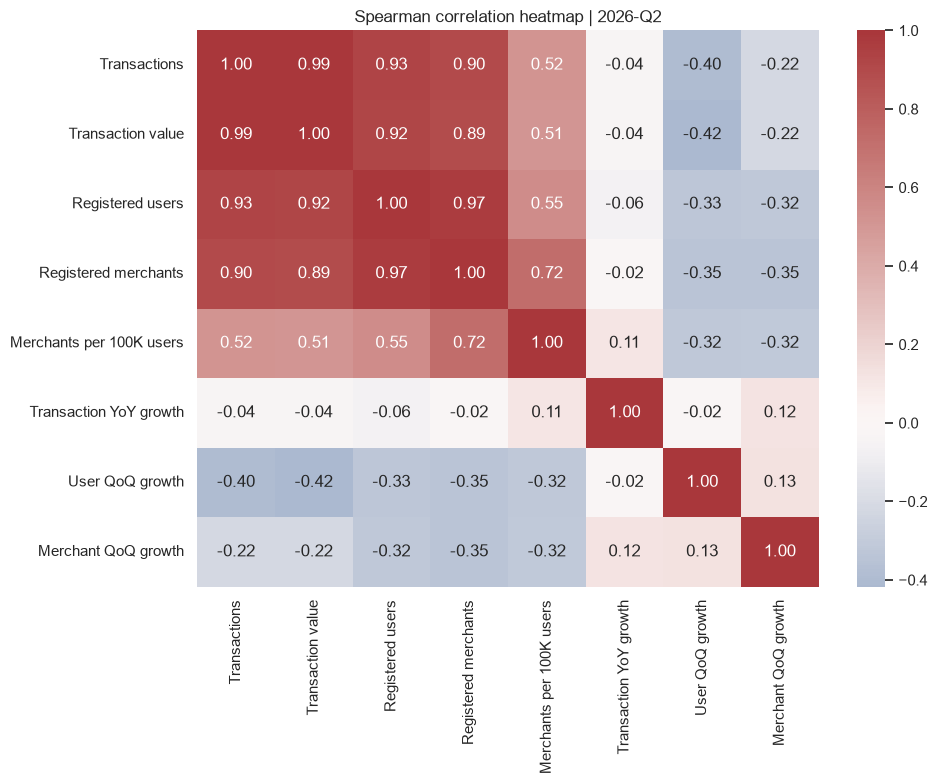

In [25]:
correlation_columns = [
    "transaction_count",
    "transaction_amount",
    "registered_users",
    "registered_merchants",
    "merchants_per_100k_users",
    "transaction_yoy",
    "user_qoq",
    "merchant_qoq",
]
correlation_labels = [
    "Transactions",
    "Transaction value",
    "Registered users",
    "Registered merchants",
    "Merchants per 100K users",
    "Transaction YoY growth",
    "User QoQ growth",
    "Merchant QoQ growth",
]

spearman_correlation = latest_districts[correlation_columns].corr(
    method="spearman"
)

fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    xticklabels=correlation_labels,
    yticklabels=correlation_labels,
    ax=axis,
)
axis.set_title(f"Spearman correlation heatmap | {latest_period}")
fig.tight_layout()
plt.show()

### Insight

Transaction count and value have the strongest relationship at **0.994**. Users, merchants, and transactions are also strongly related, so using all of them with large weights could duplicate market scale. **Correlation does not imply causation.**

## 12. Transaction Category Analysis

,category,transaction_count,category_share
1,Retail,24691181013,0.639
0,P2P,11889781621,0.308
2,Utility,2083323057,0.054


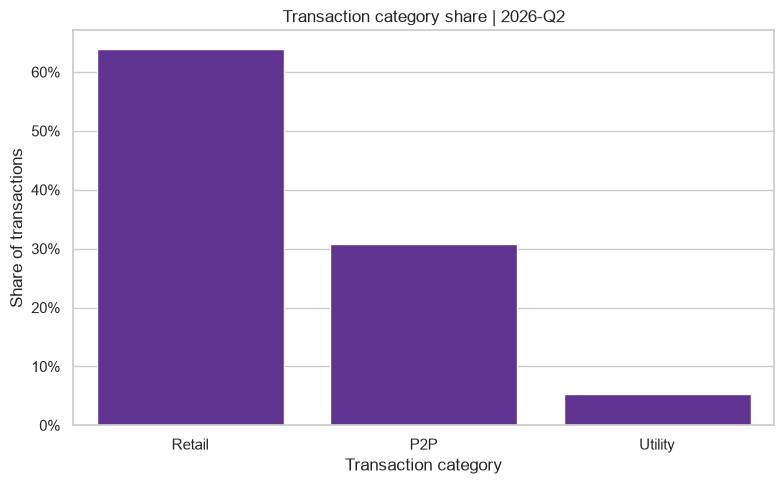

In [26]:
latest_category_data = category_data.loc[
    category_data["period_id"].eq(latest_period_id)
].copy()
category_summary = (
    latest_category_data.groupby("category", as_index=False)[
        "transaction_count"
    ]
    .sum()
    .sort_values("transaction_count", ascending=False)
)
category_summary["category_share"] = (
    category_summary["transaction_count"]
    / category_summary["transaction_count"].sum()
)
display(category_summary.round(3))

fig, axis = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=category_summary,
    x="category",
    y="category_share",
    color=purple,
    ax=axis,
)
axis.yaxis.set_major_formatter(PercentFormatter(1))
axis.set_title(f"Transaction category share | {latest_period}")
axis.set_xlabel("Transaction category")
axis.set_ylabel("Share of transactions")
fig.tight_layout()
plt.show()

### Insight

**Retail** is the largest category, representing **63.9%** of 2026-Q2 transactions. District totals include ecosystem activity and must not automatically be interpreted as merchant-only payment transactions.

## 13. Final EDA Insights

1. National transactions reached **38.66 billion**, with **6.7% QoQ growth**. This shows current ecosystem momentum and supports district-level merchant research.

2. National transaction value reached **INR 45.50 trillion**. Value confirms market scale but cannot be treated as merchant revenue.

3. **Maharashtra** leads state transaction volume. The top five states contribute **52.6%**, so activity is geographically concentrated.

4. **Bengaluru Urban** leads district transactions with **2,113,433,404**. Its scale makes it operationally important, although size alone does not prove an expansion gap.

5. Median merchant penetration among sizeable districts is **6,441 merchants per 100K users**. Districts below this level need demand and growth evidence before prioritisation.

6. **Darrang** has the fastest sizeable-district YoY growth at **52.4%**. The result should be interpreted with its transaction and user base.

7. User growth exceeds merchant growth in **49.7% of sizeable districts**. These markets may deserve merchant-coverage investigation, subject to active-participant data.

8. Users and transactions have a **0.898 Spearman correlation**. This strong overlap means scale measures should not all dominate the final score.

9. The high-growth, low-penetration quadrant contains **146 districts (21.5%)**. **Maharashtra** has the largest candidate count and deserves deeper scoring.

10. **Retail** represents **63.9%** of current transactions. Category mix confirms that district transaction totals are broader than merchant payments.